In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold0_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold1_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold2_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
len(df)

164

In [7]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [17]:
df

,chrom,fold,PearsonR,centered_start,centered_end,centered_flat_start,centered_flat_end,active_fraction,neutral_fraction,repressive_fraction,...,GC_seq,GC_slice,GC_slice_edited,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,URQ_delta
0,chr1,0,0.861165,37799936,39110656,192,320,0.391304,0.521739,0.086957,...,0.439010,0.459961,0.480469,0,0,0.0,0.0,no,(),-0.016288
2,chr3,0,0.670098,38524928,39835648,144,368,0.483871,0.516129,0.000000,...,0.404138,0.437988,0.458984,0,0,0.0,0.0,no,(),-0.164062
4,chr3,0,0.676442,119885824,121196544,154,358,0.500000,0.500000,0.000000,...,0.400891,0.408203,0.472656,1,0,0.0,0.0,no,(),-0.156949
5,chr3,0,0.681364,101859328,103170048,202,310,0.371429,0.514286,0.114286,...,0.433645,0.433594,0.436035,0,0,0.0,0.0,no,(),-0.073462
6,chr3,0,0.684073,99010560,100321280,163,349,0.476190,0.523810,0.000000,...,0.410239,0.428711,0.455566,0,0,0.0,0.0,no,(),-0.042994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,chr7,2,0.885965,72183808,73494528,187,325,0.461538,0.538462,0.000000,...,0.423994,0.423340,0.448730,0,0,0.0,0.0,no,(),-0.140906
157,chr9,2,0.792664,104148992,105459712,173,339,0.485714,0.514286,0.000000,...,0.426892,0.441406,0.440430,0,0,0.0,0.0,no,(),-0.113352
159,chr9,2,0.841365,101357568,102668288,121,391,0.460317,0.507937,0.031746,...,0.444668,0.442871,0.475586,2,0,0.0,0.0,no,(),-0.155806
160,chr9,2,0.843037,96993280,98304000,104,408,0.473684,0.508772,0.017544,...,0.434512,0.456055,0.444336,0,0,0.0,0.0,no,(),-0.134294


In [10]:
# selecting only sequences with no CTCF detected
df = df[df["CTCFs_num"] == 0]

In [13]:
# selecting only sequences with a measurable contact depletion
df = df[df['URQ_delta'] < 0.0]

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'URQ_result', 'URQ_target', 'URQ_init', 'num_edits', 'GC_seq',
       'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'URQ_delta'],
      dtype='object')

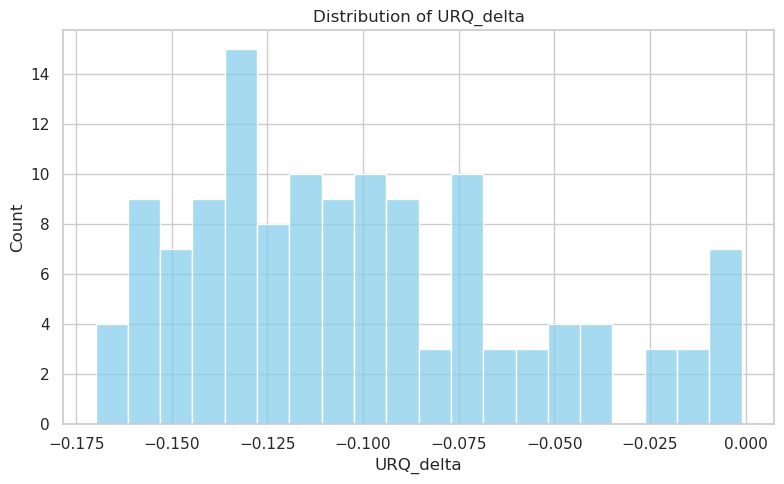

In [18]:
# Set style
sns.set(style="whitegrid")

# Plot histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['URQ_delta'], kde=False, bins=20, color='skyblue')
plt.title('Distribution of URQ_delta')
plt.xlabel('URQ_delta')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

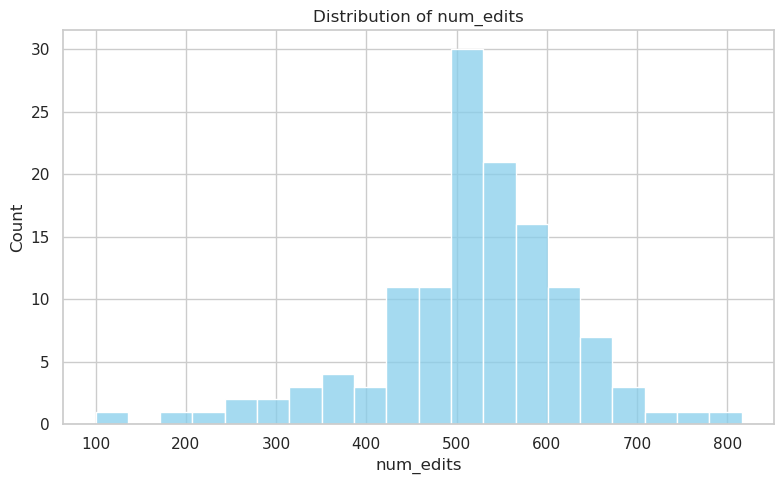

In [19]:
# Set style
sns.set(style="whitegrid")

# Plot histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['num_edits'], kde=False, bins=20, color='skyblue')
plt.title('Distribution of num_edits')
plt.xlabel('num_edits')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import ttest_rel

In [22]:
t_stat, p_value = ttest_rel(df['URQ_result'], df['URQ_init'])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3e}")

Paired t-test: t = -25.976, p = 4.326e-53


/tmp/SLURM_1430092/ipykernel_3151364/37498576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')


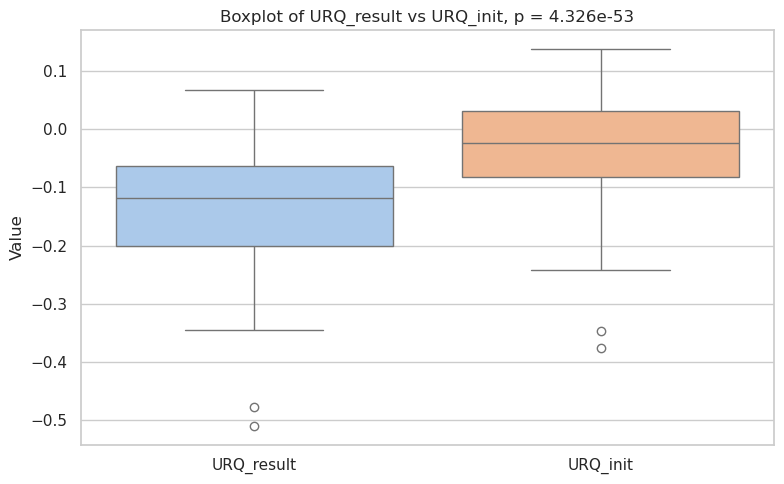

In [24]:
# Reshape for seaborn boxplot
df_melted = df[['URQ_result', 'URQ_init']].melt(var_name='Condition', value_name='Value')

plt.figure(figsize=(8, 5))
sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')
plt.title(f'Boxplot of URQ_result vs URQ_init, p = {p_value:.3e}')
plt.xlabel('')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [26]:
t_stat, p_value = ttest_rel(df['GC_slice'], df['GC_slice_edited'])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3e}")

Paired t-test: t = -10.886, p = 5.606e-20


/tmp/SLURM_1430092/ipykernel_3151364/1938061034.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')


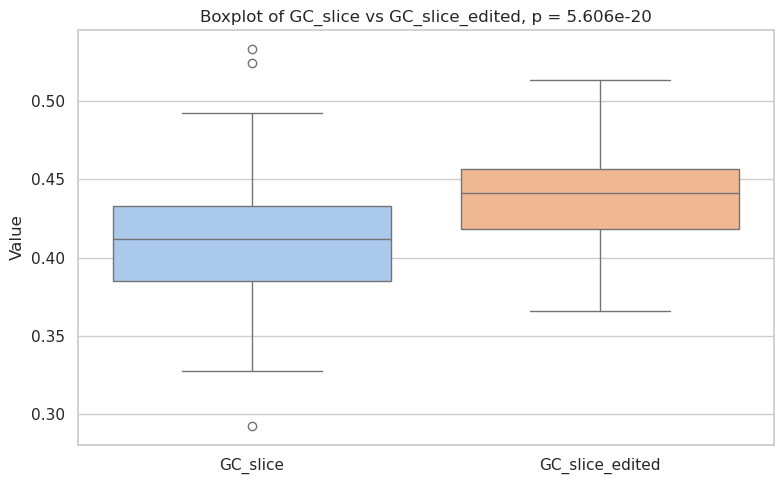

In [27]:
# Reshape for seaborn boxplot
df_melted = df[['GC_slice', 'GC_slice_edited']].melt(var_name='Condition', value_name='Value')

plt.figure(figsize=(8, 5))
sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')
plt.title(f'Boxplot of GC_slice vs GC_slice_edited, p = {p_value:.3e}')
plt.xlabel('')
plt.ylabel('Value')
plt.tight_layout()
plt.show()